## Protein-protein interaction evaluation
Processing interactions from data/graph_master_part100_*.json files

In [141]:
import os
import re
import csv
import json
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed
from io import StringIO 
from tqdm import tqdm
from glob import glob
from goatools.obo_parser import GODag
from goatools.anno.gaf_reader import GafReader
from goatools.semantic import TermCounts, get_info_content, resnik_sim

# === CONFIG ===
SPECIES = [9606, 10090, 7227] # human, mouse, fly
GO_DATA_DIR = "go-data" # Gene ontology file for getting DAG structure/relationships
go_dag = GODag("go-data/go.obo") # Gene annotation file for computing term frequencies for information content (IC)
gaf_files = ['goa_human.gaf', 'mgi.gaf', 'fb.gaf'] # human, mouse, fly
DATA_DIR = '../static/data'
OUTPUT_DIR = "../static/data/graph_master_scored"
FILE_PATTERN = os.path.join(DATA_DIR, "graph_master_part100_*.json")
files = sorted(glob(FILE_PATTERN))
print(f"Found {len(files)} files.")

go-data/go.obo: fmt(1.2) rel(2025-07-22) 43,230 Terms
Found 194 files.


### Building information content (IC) for all terms
- Low IC -> common term
- High IC -> rare term

In [98]:
def build_annotations(gaf_files):
    """Reading and locally storing annotations for BP, MF, and CC terms from GAF files."""
    annotations = {"BP": {}, "MF": {}, "CC": {}}
    
    for gaf_file in gaf_files:
        gaf = GafReader(os.path.join(GO_DATA_DIR, gaf_file))
        ns2assc = gaf.get_ns2assc()
        for ns in annotations.keys():
            annots_ns = ns2assc.get(ns, {})
            for gene, gos in annots_ns.items():
                annotations[ns].setdefault(gene, set()).update(gos)
    
    return annotations

def build_ic(annotations):
    """Build information content (IC) for BP, MF, and CC terms from annotations."""
    termcounts = {}
    ic = {}
    for ns in annotations.keys():
        tc = TermCounts(go_dag, annotations[ns])
        termcounts[ns] = tc
        ic[ns] = {go_id: get_info_content(go_id, tc)
                       for go_id in tc.go2genes}

    return ic, termcounts

In [80]:
annotations = build_annotations(gaf_files)

HMS:0:00:15.517333 993,392 annotations READ: go-data/goa_human.gaf 
HMS:0:00:13.834766 785,576 annotations READ: go-data/mgi.gaf 
HMS:0:00:00.749600 138,322 annotations READ: go-data/fb.gaf 


In [99]:
ic, termcounts = build_ic(annotations)

### Processing interaction pair

In [ ]:
def chunked(lst, n):
    """Yield successive n-sized chunks from lst"""
    for i in range(0, len(lst), n):
        yield lst[i:i + n]

def fetch_uniprot_bulk(proteins, species_list):
    """
    Fetch UniProt info for a list of proteins in bulk.
    Returns a dict: protein_id.upper() -> UniProt data dict
    """
    species_filter = " OR ".join(f"organism_id:{sp}" for sp in species_list)
    protein_lookup = {}
    chunk_size = 20
    for batch in chunked(list(proteins), chunk_size):
        query = f"({' '.join(batch)}) AND {species_filter}"
        url = "https://rest.uniprot.org/uniprotkb/search"
        params = {
            "query": query,
            "format": "tsv",
            "fields": "accession,id,protein_name,gene_names,organism_id,go_f,go_c,go_p"
        }
        try:
            r = requests.get(url, params=params, timeout=30)
            r.raise_for_status()
            lines = r.text.strip().split("\n")
            headers = lines[0].split("\t")
            for line in lines[1:]:
                values = line.split("\t")
                entry = dict(zip(headers, values))
                for original in batch:
                    protein_lookup[original.upper()] = entry
        except requests.exceptions.RequestException as e:
            print(f"UniProt bulk request failed for batch: {e}")
    
    return protein_lookup

def go_label(go_id):
        """Helper to get GO name."""
        return go_dag[go_id].name if go_id in go_dag else "Unknown term"

def compute_resnik_sim(protein_a, protein_b, lookup, ic):
    """Compute Resnik similarity of two proteins using GO terms."""

    def extract_go_terms(protein_id, ns="BP"):
        info = lookup.get(protein_id, {})
        info_terms = {"BP": "Gene Ontology (biological process)",
                      "MF": "Gene Ontology (molecular function)",
                      "CC": "Gene Ontology (cellular component)"
                    }
        go_terms = info.get(info_terms[ns], "")
        # Take a set of 'name [GO:xxxx]' strings and return just GO:IDs
        go_ids = set()
        for t in go_terms.split(";"):
            match = re.search(r"(GO:\d+)", t)
            if match:
                go_ids.add(match.group(1))
        return go_ids
    
    def mica_and_resnik(go1, go2, ic_ns="BP"):
        """Return (mica_term, resnik_ic)."""
        ic_lookup = ic.get(ic_ns, {})

        if go1 not in go_dag or go2 not in go_dag:
            return None, 0.0

        anc1 = go_dag[go1].get_all_parents().union({go1})
        anc2 = go_dag[go2].get_all_parents().union({go2})
        common = anc1.intersection(anc2)

        if not common:
            return None, 0.0

        # Best MICA = ancestor with highest IC
        mica = max(common, key=lambda t: ic_lookup.get(t, 0.0))
        return mica, ic_lookup.get(mica, 0.0)

    # Compute all term–term Resnik similarities
    results = {}
    scores = []
    species = list({
        lookup.get(protein_a, {}).get("Organism (ID)", ""),
        lookup.get(protein_b, {}).get("Organism (ID)", "")
    })

    for ns in ["BP", "MF", "CC"]:
        a_terms = extract_go_terms(protein_a, ns)
        b_terms = extract_go_terms(protein_b, ns)

        if not a_terms or not b_terms:
            return {"score": 0.0, "BP_terms": [], "MF_terms": [], "CC_terms": [], "species": species}

        scored_pairs = []
        for a_go in a_terms:
            for b_go in b_terms:
                mica, mica_ic = mica_and_resnik(a_go, b_go, ns)
                if mica:
                    scored_pairs.append((a_go, b_go, mica, mica_ic))

                    # OLD (only returns score, not mica/ic)
                    # sim = resnik_sim(a, b, go_dag, termcounts)
                    # scored_pairs.append((a, b, sim))

        if not scored_pairs:
            results[ns] = None
            continue

        scored_pairs.sort(key=lambda x: x[3], reverse=True)
        go_a, go_b, mica, mica_ic = scored_pairs[0]

        ic_ns = ic.get(ns, {})
        max_ic = max(ic_ns.values()) if ic_ns else 1.0
        normalized = mica_ic / max_ic

        results[ns] = {
            "score": round(normalized, 3),
            "go_a": {"id": go_a, "name": go_dag[go_a].name},
            "go_b": {"id": go_b, "name": go_dag[go_b].name},
            "mica": {
                "id": mica,
                "name": go_dag[mica].name,
                "depth": go_dag[mica].depth,
            },
            "ic_go_a": ic_ns.get(go_a, 0.0) / max_ic,
            "ic_go_b": ic_ns.get(go_b, 0.0) / max_ic,
            "ic_mica": normalized,
        }

        scores.append(normalized)

    max_score = max(scores) if scores else 0.0

    return {
        "score": max_score,
        "BP_terms": results["BP"],
        "MF_terms": results["MF"],
        "CC_terms": results["CC"],
        "species": species,
    }

### Scoring all predicted protein pairs

In [125]:
import requests
from collections import defaultdict

def process_interaction(protein_a, protein_b, network_lookup, protein_info_lookup, ic):
    A = protein_a.upper()
    B = protein_b.upper()

    edges = network_lookup.get((A, B), [])

    # ----------------------------
    # STRING FOUND → use score
    # ----------------------------
    if edges:
        edges_sorted = sorted(edges, key=lambda x: x.get("score", 0.0), reverse=True)
        best = edges_sorted[0]
        
        species_list = [e.get("ncbiTaxonId") for e in edges_sorted]

        return {
            "score": best.get("score", 0.0),
            "scores": edges_sorted,    # full STRING scores list
            "species": species_list,
            "type": "STRING"
        }

    # ----------------------------
    # STRING NOT FOUND → use Resnik similarity of GO terms
    # ----------------------------
    resnik = compute_resnik_sim(protein_a, protein_b, protein_info_lookup, ic)
    return {
        "score": resnik["score"],
        "type": "GO-Resnik",
        "scores": {"BP_terms": resnik["BP_terms"], "MF_terms": resnik["MF_terms"], "CC_terms": resnik["CC_terms"]},
        "species": resnik["species"]
    }

def fetch_string_bulk(protein_pairs, species):
    """Return dict mapping (A,B) → list-of-score-dicts or empty list."""
    url = "https://string-db.org/api/json/network"
    id_str = "%0d".join([f"{a}%0d{b}" for a, b in protein_pairs])
    params = {"identifiers": id_str, "species": species}

    try:
        r = requests.get(url, params=params, timeout=15)
        r.raise_for_status()
        data = r.json()

        lookup = defaultdict(list)
        for edge in data:
            a = edge.get("preferredName_A", "").upper()
            b = edge.get("preferredName_B", "").upper()
            lookup[(a, b)].append(edge)
            lookup[(b, a)].append(edge)

        return lookup

    except Exception as e:
        # print(f"STRING bulk error: {e}")
        return defaultdict(list)

### Processing files

In [140]:
files

['../static/data/graph_master_scored/graph_master_part100_0.json',
 '../static/data/graph_master_scored/graph_master_part100_1.json',
 '../static/data/graph_master_scored/graph_master_part100_10.json',
 '../static/data/graph_master_scored/graph_master_part100_11.json',
 '../static/data/graph_master_scored/graph_master_part100_12.json',
 '../static/data/graph_master_scored/graph_master_part100_13.json',
 '../static/data/graph_master_scored/graph_master_part100_14.json',
 '../static/data/graph_master_scored/graph_master_part100_15.json',
 '../static/data/graph_master_scored/graph_master_part100_16.json',
 '../static/data/graph_master_scored/graph_master_part100_17.json',
 '../static/data/graph_master_scored/graph_master_part100_18.json',
 '../static/data/graph_master_scored/graph_master_part100_19.json',
 '../static/data/graph_master_scored/graph_master_part100_2.json',
 '../static/data/graph_master_scored/graph_master_part100_20.json',
 '../static/data/graph_master_scored/graph_master_p

In [142]:
def extract_number(filename):
    match = re.search(r'(\d+)\.json$', filename)
    return int(match.group(1)) if match else -1

files = sorted(files, key=extract_number)
filelist = files[:193]
# filelist = files[1:2] # testing on a single file

for file in filelist:
    with open(file) as f:
        data = json.load(f)

    links = data.get("links", [])
    protein_pairs = [(l["source"], l["target"]) for l in links]

    unique_proteins = set()
    for src, tgt in protein_pairs:
        unique_proteins.add(src.upper())
        unique_proteins.add(tgt.upper())

    # ---------------------------
    # fetching protein info from Uniprot in bulk
    # ---------------------------
    protein_lookup = fetch_uniprot_bulk(list(unique_proteins), SPECIES)

    # ---------------------------
    # fetching STRING interactions in bulk
    # ---------------------------
    per_species = {sp: fetch_string_bulk(protein_pairs, sp) for sp in SPECIES}

    unified = defaultdict(list)
    for sp_lookup in per_species.values():
        for key, edges in sp_lookup.items():
            unified[key].extend(edges)

    new_links = []
    with ThreadPoolExecutor(max_workers=4) as executor:
        futures = {
            executor.submit(process_interaction, l['source'], l['target'], unified, protein_lookup, ic): l
            for l in links
        }
        for future in tqdm(as_completed(futures), total=len(links), desc=f"Processing links in {file}"):
            link = futures[future]
            result = future.result()

            new_link = {
                "source": link["source"],
                "target": link["target"],
                "id": link["id"],
                **result
            }
            if "color" in link:
                new_link["color"] = link["color"]
            if "penwidth" in link:
                new_link["penwidth"] = link["penwidth"]

            new_links.append(new_link)

    data["links"] = new_links

    # saving new data
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    filename = os.path.basename(file)
    outname = os.path.join(OUTPUT_DIR, filename)
    with open(outname, "w") as f:
        json.dump(data, f, indent=2)

Processing links in ../static/data/graph_master_part100_0.json: 100%|██████████| 1/1 [00:00<00:00, 13706.88it/s]
Processing links in ../static/data/graph_master_part100_1.json: 100%|██████████| 294/294 [00:00<00:00, 328483.05it/s]
Processing links in ../static/data/graph_master_part100_2.json: 100%|██████████| 342/342 [00:00<00:00, 1117.07it/s]
Processing links in ../static/data/graph_master_part100_3.json: 100%|██████████| 209/209 [00:00<00:00, 233513.46it/s]
Processing links in ../static/data/graph_master_part100_4.json: 100%|██████████| 199/199 [00:00<00:00, 414638.10it/s]
Processing links in ../static/data/graph_master_part100_5.json: 100%|██████████| 179/179 [00:00<00:00, 315056.83it/s]
Processing links in ../static/data/graph_master_part100_6.json: 100%|██████████| 161/161 [00:00<00:00, 229.11it/s]
Processing links in ../static/data/graph_master_part100_7.json: 100%|██████████| 175/175 [00:00<00:00, 319.91it/s]
Processing links in ../static/data/graph_master_part100_8.json: 100%|

In [143]:
DATA_DIR = '../static/data/graph_master_scored'
FILE_PATTERN = os.path.join(DATA_DIR, "graph_master_part100_*.json")
scored_files = sorted(glob(FILE_PATTERN))
print(f"Found {len(scored_files)} files.")

Found 193 files.


In [144]:
scores = []
total_nodes = 0
total_links = 0

for file in scored_files:
    with open(file, 'r') as f:
        data = json.load(f)
        
        nodes = data.get("nodes", [])
        links = data.get("links", [])
        total_nodes += len(nodes)
        total_links += len(links)
        print(f"{file} has {len(links)} links")
        # print(f"{file} has {len(nodes)} nodes")

        for interaction in links:
            scores.append(interaction.get("score", 0.0))

print(f"Collected {len(scores)} scores for graph size {total_nodes}, {total_links}.")

../static/data/graph_master_scored/graph_master_part100_0.json has 1 links
../static/data/graph_master_scored/graph_master_part100_1.json has 294 links
../static/data/graph_master_scored/graph_master_part100_10.json has 113 links
../static/data/graph_master_scored/graph_master_part100_100.json has 31 links
../static/data/graph_master_scored/graph_master_part100_101.json has 63 links
../static/data/graph_master_scored/graph_master_part100_102.json has 103 links
../static/data/graph_master_scored/graph_master_part100_103.json has 74 links
../static/data/graph_master_scored/graph_master_part100_104.json has 70 links
../static/data/graph_master_scored/graph_master_part100_105.json has 74 links
../static/data/graph_master_scored/graph_master_part100_106.json has 70 links
../static/data/graph_master_scored/graph_master_part100_107.json has 52 links
../static/data/graph_master_scored/graph_master_part100_108.json has 84 links
../static/data/graph_master_scored/graph_master_part100_109.json ha

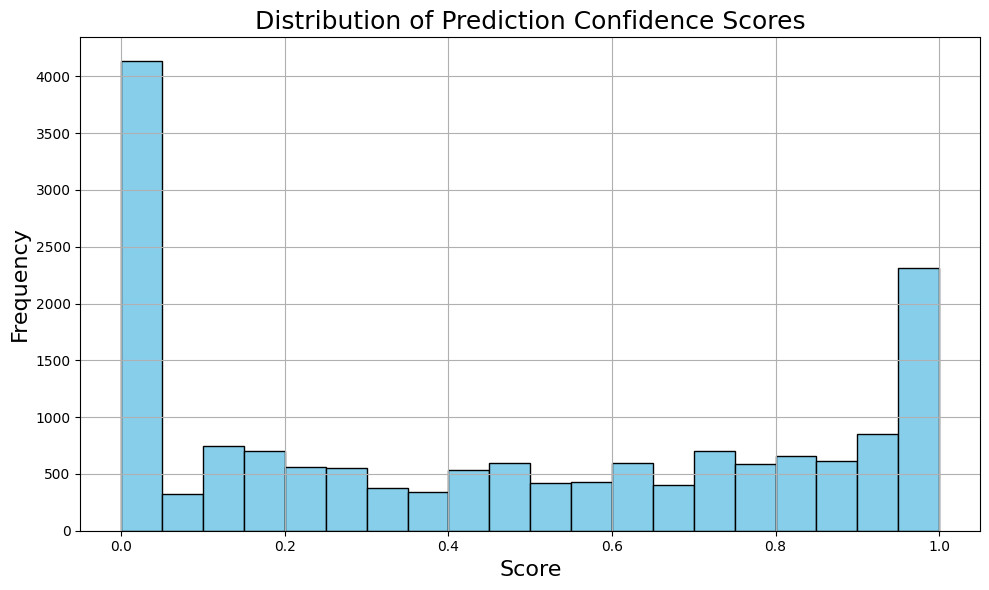

In [145]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(scores, bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Prediction Confidence Scores', fontsize=18)
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.xlabel('Score', fontsize=16)
plt.ylabel('Frequency', fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()